In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
import pandas as pd 
import seaborn as sns

# import nn PCA model from nuclear-norm-pca
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/nuclear-norm-pca')
import kuckle_model
from kuckle_model import *

### Settings and Load data

In [2]:
leaflet_repo = '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/' #need to move load_cluster_data function to general module utils 
sys.path.append(leaflet_repo)
import load_cluster_data
from betabinomo_mix_singlecells import *

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, celltypes=cell_types, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
['Brain_Non-Myeloid_brain_pericyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_endothelial_cell' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_neuron' 'Brain_Myeloid_macrophage'
 'Brain_Myeloid_microglial_cell' 'Brain_Non-Myeloid_astrocyte']
7816
16190
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-M

[0.0672032  0.01925902 0.01560112 0.01093991 0.00515439 0.00346535
 0.00298153 0.00264373 0.00224781 0.00208001]


Text(0.5, 1.0, 'PCA of Junction Usage Ratios (imputed matrix)')

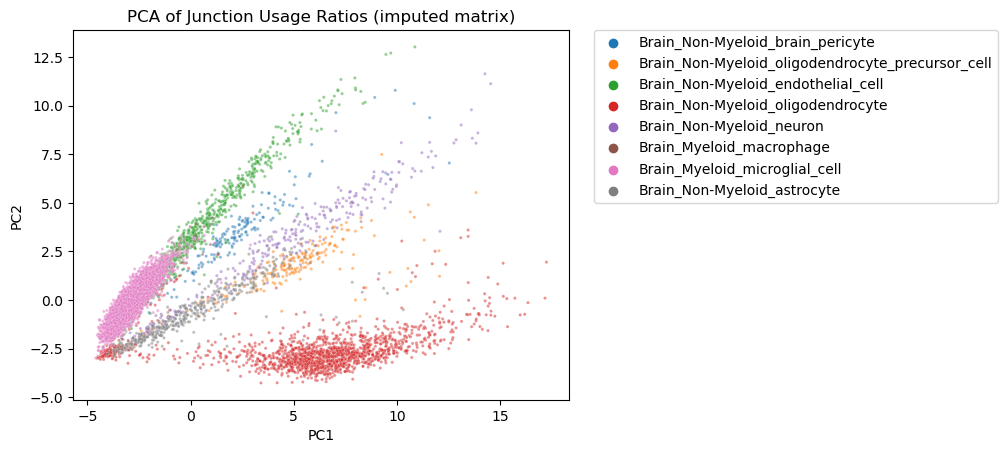

In [5]:
## simple PCA with imputation of missing values 

# make matrix of junctions by cells and fill with juncratio values 
mat = np.zeros((len(final_data.cell_id_index.unique()), len(final_data.junction_id_index.unique())))
mat[final_data.cell_id_index, final_data.junction_id_index] = final_data.juncratio
mat[~(final_data.cell_id_index), ~(final_data.junction_id_index)] = np.nan

# imput nan values using mean of each row (does this make sense?)
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(mat)
mat_imputed = imp.transform(mat)

# run PCA on mat_imputed 
pca = PCA(n_components=10)
pca.fit(mat_imputed)
print(pca.explained_variance_ratio_)

pcs = pca.transform(mat_imputed)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

# plot first two PCs
sns.scatterplot(data=pcs_df, x="PC1", y="PC2", hue=cell_types_pcs.values, s=5, alpha=0.5)
# move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Junction Usage Ratios (imputed matrix)")

In [6]:
# let's use PCs to get silhouette scores via cell type labels 
# import silhouette_score
from sklearn.metrics import silhouette_score
print(silhouette_score(pcs, cell_ids_conversion.cell_type.values)) # likely inflated by the imputation which may just reflect global gene expression trends?

# get Davies-Bouldin Index
from sklearn.metrics import davies_bouldin_score
print(davies_bouldin_score(pcs, cell_ids_conversion.cell_type.values)) # lower is better

0.28746580807753086
1.5213457171271207


### Filter junctions and set up Y and W (weight matrix of inverse variances of the PSI values)

also printing original indices of junctions we are keeping


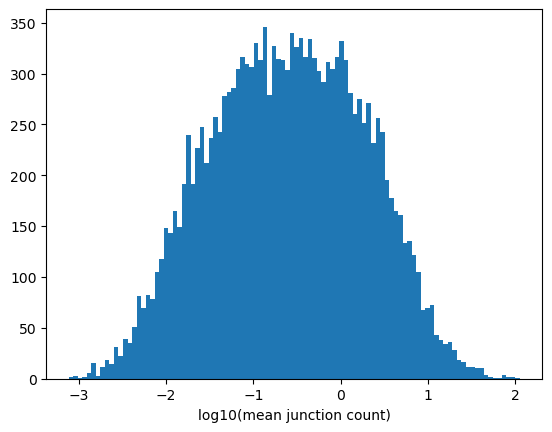

In [7]:
junc_counts_sub, cluster_counts_sub, junc_keep = filter_junctions(
    junc_counts, cluster_counts, plot = True)

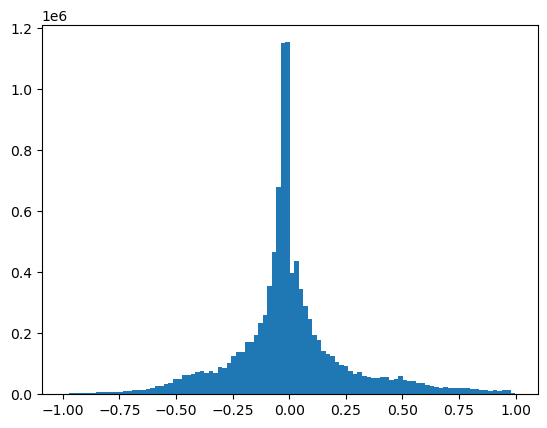

In [8]:
# set up data for nuc norm PCA
Y_data, w = make_Y(
    junc_counts_sub, cluster_counts_sub, float_type)

# np.mean(Y_data * Y_data) * psi.shape[0] * psi.shape[1]
Y = torch.tensor(Y_data, **float_type)
W = torch.tensor(w.data, **float_type)

_ = plt.hist(Y_data, 100) # centered so the distribution peaks at 0 and is in [-1,1]

### Split into training and test data 

In [9]:
Y_train, W_train, indices_train, Y_test, W_test, indices_test = train_test(
    Y_data, w, float_type)

### Run nuclear norm PCA constraint search 

In [10]:
rmseTol = 5e-5
its=10

rs, testErrors, trainErrors, nuc_norms, final_svd, step_times = constraint_search(
    indices_train, 
    Y_train, 
    W_train, 
    size = junc_counts_sub.shape,
    indices_test = indices_test, 
    Y_test = Y_test, 
    W_test = W_test, 
    rmseTol = rmseTol, 
    end = "\n",
    inner_verbose = True,
    power_iteration_controller = (30,1.),
    its = its,  
    **float_type)

CV	Bound	RMSE	TestRMSE
It	RMSE	Step	DeltaRMSE


/gpfs/commons/home/kisaev/Leaflet-private/src/nuclear-norm-pca/kuckle_model.py:311: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi, dtype = float_type["dtype"], device = "cpu") # this is always on CPU


CV	1e+03	0.227	0.23
It	RMSE	Step	DeltaRMSE
CV	1.5e+03	0.223	0.2282608
It	RMSE	Step	DeltaRMSE
CV	2.25e+03	0.219	0.227865
It	RMSE	Step	DeltaRMSE
CV	3.38e+03	0.216	0.226684
It	RMSE	Step	DeltaRMSE
CV	5.06e+03	0.213	0.2265487
It	RMSE	Step	DeltaRMSE
CV	7.59e+03	0.21	0.22503113
It	RMSE	Step	DeltaRMSE
CV	1.14e+04	0.207	0.2252855
It	RMSE	Step	DeltaRMSE
CV	1.71e+04	0.204	0.2242571
It	RMSE	Step	DeltaRMSE
CV	2.56e+04	0.202	0.2242855
It	RMSE	Step	DeltaRMSE
CV	3.84e+04	0.199	0.22486808
It	RMSE	Step	DeltaRMSE
CV	5.77e+04	0.197	0.22402489
It	RMSE	Step	DeltaRMSE
CV	8.65e+04	0.194	0.22402797
It	RMSE	Step	DeltaRMSE


### Plot results 

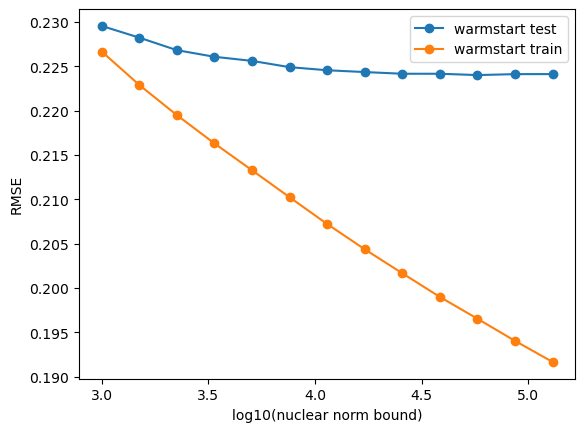

In [11]:
plt.plot(np.log10(rs), testErrors,"-o", label = "warmstart test") #rs = list of nuclear norm bounds used 
plt.plot(np.log10(rs), trainErrors, "-o", label = "warmstart train")
plt.ylabel("RMSE")
plt.xlabel("log10(nuclear norm bound)")
plt.legend()

tensor(4680.7974)

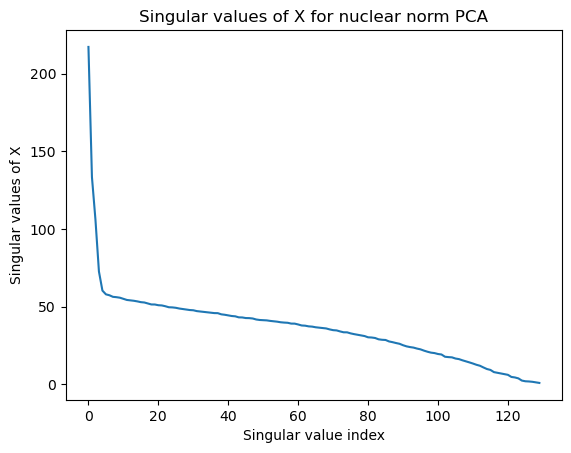

In [12]:
plt.plot(final_svd.S)
plt.ylabel("Singular values of X") 
plt.xlabel("Singular value index")
# add title
plt.title("Singular values of X for nuclear norm PCA")
final_svd.S.sum()

Text(0, 0.5, 'log10(Nuc norm obtained)')

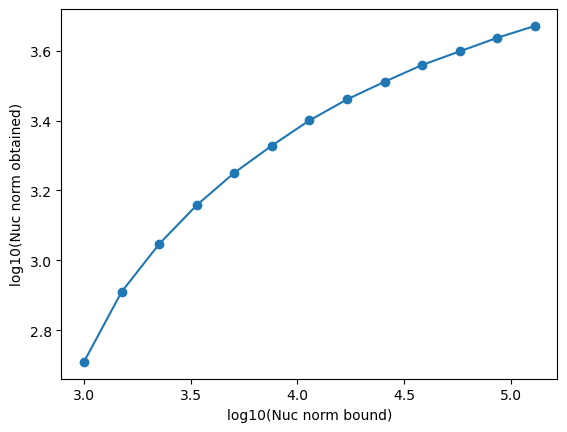

In [13]:
# solution is on the boundary up to about ~1e4, then is inside. 
plt.plot(np.log10(rs), np.log10(nuc_norms), "-o", label = "warmstart")
plt.xlabel("log10(Nuc norm bound)")
plt.ylabel("log10(Nuc norm obtained)")

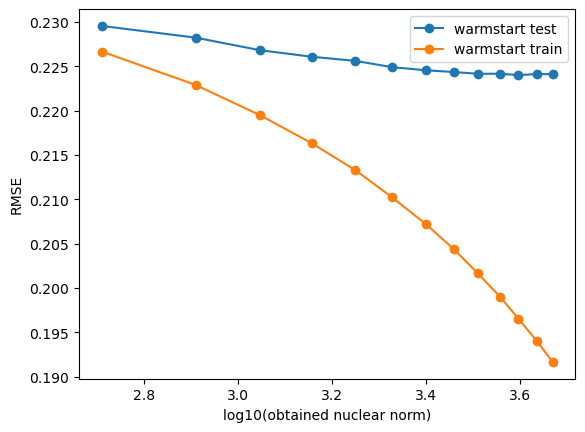

In [14]:
plt.plot(np.log10(nuc_norms), testErrors,"-o", label = "warmstart test")
plt.plot(np.log10(nuc_norms), trainErrors, "-o", label = "warmstart train")
plt.ylabel("RMSE")
plt.xlabel("log10(obtained nuclear norm)")
plt.legend()

In [15]:
r_best = rs[np.argmin(testErrors)]
Y,W,indices = to_torch(Y_data, w, **float_type)

### Re-run constraint_search with our best r_best

In [16]:
rs, _, trainErrors_all, nuc_norms_all, final_svd_all, step_times = constraint_search(
    indices, 
    Y, 
    W, 
    size = junc_counts_sub.shape,
    rmseTol = rmseTol, 
    its = its,  
    max_r = r_best, 
    end = "\n",
    **float_type)


CV	Bound	RMSE	TestRMSE
CV	1e+03	0.227	nan
CV	1.5e+03	0.224	nan
CV	2.25e+03	0.22	nan
CV	3.38e+03	0.218	nan
CV	5.06e+03	0.215	nan
CV	7.59e+03	0.212	nan
CV	1.14e+04	0.21	nan
CV	1.71e+04	0.207	nan
CV	2.56e+04	0.205	nan
CV	3.84e+04	0.202	nan
CV	5.77e+04	0.2	nan


In [17]:
print("The best nuclear norm bound:", r_best)

The best nuclear norm bound: 57665.0390625


### Settings and Load data

Text(0.5, 1.0, 'Singular values of X for nuclear norm PCA')

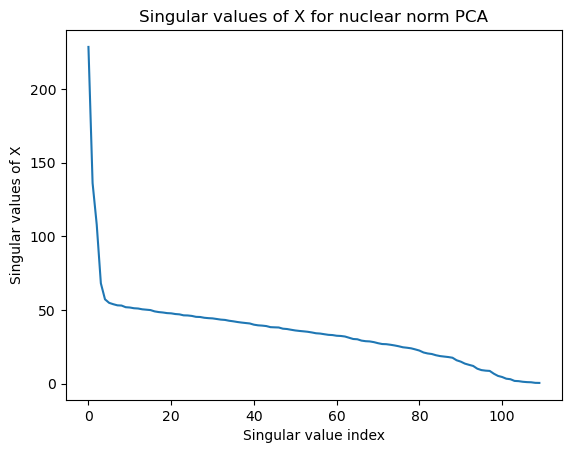

In [18]:
plt.plot(final_svd_all.S) # final_svd = orthonormer(U, V, phi) --> orthonormalization process on the singular vectors (stored in U and V) and singular values (phi) obtained from the nuc_norm_PCA
plt.xlabel("Singular value index")
plt.ylabel("Singular values of X")
plt.title("Singular values of X for nuclear norm PCA")

In [19]:
# convert to df and rename columns to be PCA_1, PCA_2, etc.
PC_df = pd.DataFrame(final_svd_all.U)
PC_df.columns = ["PCA_" + str(i) for i in range(1, PC_df.shape[1] + 1)]
PC_df["cell_type"] = cell_ids_conversion["cell_type"].to_numpy()
PC_df

,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,...,PCA_102,PCA_103,PCA_104,PCA_105,PCA_106,PCA_107,PCA_108,PCA_109,PCA_110,cell_type
0,0.008801,-0.002940,0.017356,-4.364126e-03,-0.023182,-0.021573,0.002165,-0.000169,0.003390,-0.002871,...,0.008905,-0.002697,0.003250,0.004458,0.001561,-0.001946,-0.011465,0.003125,-0.003421,Brain_Non-Myeloid_brain_pericyte
1,0.005406,-0.003506,0.032837,-3.574455e-03,-0.023457,0.019071,0.018055,0.010835,-0.005846,-0.003583,...,0.003752,0.017048,0.007763,0.011030,0.004424,0.004127,-0.001998,0.006242,-0.005198,Brain_Non-Myeloid_brain_pericyte
2,0.006660,-0.005176,0.008345,7.125615e-03,-0.012138,-0.011695,-0.002915,0.009872,-0.000501,-0.001929,...,0.002581,-0.000666,0.012323,-0.003028,0.000382,0.007718,-0.004256,0.001576,-0.003161,Brain_Non-Myeloid_brain_pericyte
3,0.002603,-0.003865,0.028702,-5.303361e-03,-0.064970,-0.023992,0.014509,-0.013175,-0.003265,0.012043,...,-0.013100,0.004496,-0.013291,-0.008016,-0.002468,0.007804,-0.003349,-0.013083,-0.008959,Brain_Non-Myeloid_brain_pericyte
4,0.005519,-0.002374,0.042259,1.935845e-02,-0.072500,-0.020504,0.022245,-0.015688,-0.013207,-0.011949,...,-0.013064,-0.008135,-0.007486,0.028815,0.022459,0.003100,0.008204,0.010644,-0.010108,Brain_Non-Myeloid_brain_pericyte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7811,-0.002482,-0.001306,0.001777,-5.172226e-08,0.001036,-0.009939,0.005959,0.003233,0.003928,0.005878,...,0.008881,0.000482,0.000019,0.000973,-0.008647,0.002615,0.000772,0.012907,-0.001926,Brain_Non-Myeloid_astrocyte
7812,-0.003024,0.001766,0.000221,1.532463e-03,0.002183,0.000442,0.005820,-0.000580,-0.000513,0.001476,...,-0.001525,0.000547,0.004570,0.003658,0.002221,-0.002632,0.002302,-0.004649,0.002593,Brain_Non-Myeloid_astrocyte
7813,-0.002343,-0.000577,0.001260,1.470044e-02,0.010923,-0.011303,0.001507,0.004482,-0.003041,-0.004022,...,0.001214,0.000487,-0.014425,0.003316,-0.007857,-0.012336,0.001929,-0.029817,0.004214,Brain_Non-Myeloid_astrocyte
7814,-0.004700,0.002430,-0.004507,1.811360e-03,-0.009418,-0.018077,0.007436,0.008431,-0.000643,0.020480,...,-0.010924,0.010036,0.005055,-0.002455,0.003003,-0.009442,-0.011818,-0.002142,-0.001533,Brain_Non-Myeloid_astrocyte


<Axes: xlabel='PCA_1', ylabel='PCA_2'>

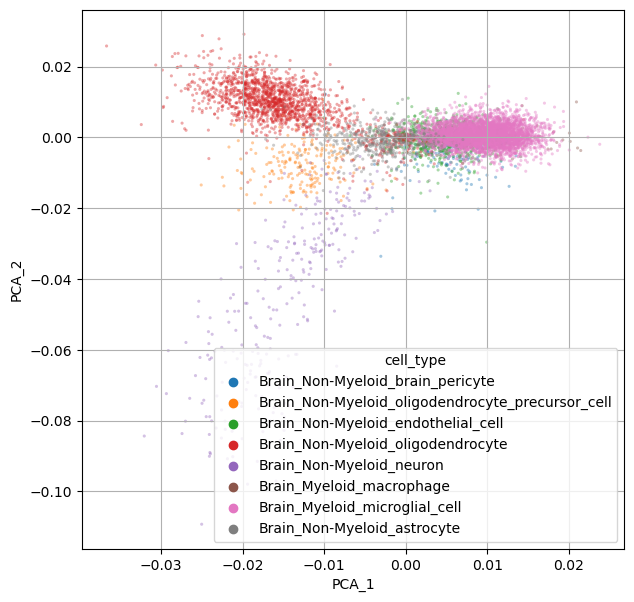

In [20]:
plt.figure(figsize=[7,7])
plt.grid()
sns.scatterplot(x = "PCA_1",y = "PCA_2", hue="cell_type", data= PC_df, edgecolor = 'none', alpha = 0.4, s=5)

Text(0.5, 0, 'Singular value index')

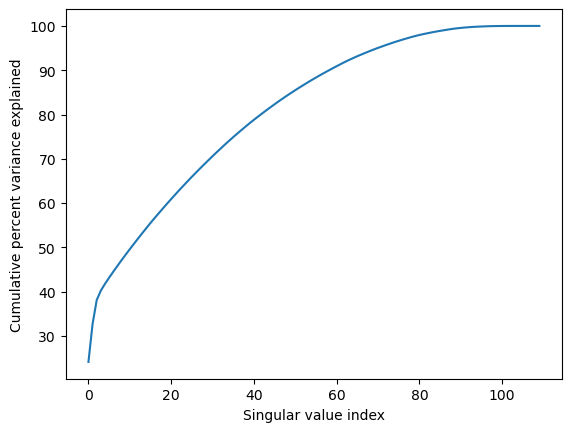

In [21]:
pve = final_svd_all.S**2
pve /= pve.sum()
pve = pve.cumsum(0) * 100
plt.plot(pve)
plt.ylabel("Cumulative percent variance explained")
# add xlabel
plt.xlabel("Singular value index")

In [22]:
E = final_svd_all.U * final_svd_all.S  #in U, these are like the PCs..., S are the scaling factors that quantify the amount of variance captured by each corresponding singular vector in U.

In [23]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

(array([1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 2.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 2.00000e+00, 3.00000e+00, 1.00000e+00, 1.00000e+00,
        3.00000e+00, 5.00000e+00, 3.00000e+00, 4.00000e+00, 3.00000e+00,
        4.00000e+00, 9.00000e+00, 3.00000e+00, 4.00000e+00, 3.00000e+00,
        4.00000e+00, 6.00000e+00, 5.00000e+00, 3.00000e+00, 7.00000e+00,
        9.00000e+00, 8.00000e+00, 6.00000e+00, 2.00000e+00, 3.00000e+00,
        4.00000e+00, 5.00000e+00, 8.00000e+00, 1.20000e+01, 8.00000e+00,
        1.20000e+01, 1.60000e+01, 2.50000e+01, 3.00000e+01, 5.80000e+01,
        4.50000e+01, 6.50000e+01, 8.40000e+01, 1.03000e+02, 1.43000e+02,
        1.47000e+02, 1.64000e+02, 1.69000e+02, 1.84000e+02, 1.61000e+02,
        1.77000e+02, 2.05000e+02, 2.16000e+02, 2.87000e+02, 3.48000e+02,
        5.41000e+02, 7.55000e+02, 1.27600e+03, 2.24000e+03, 4.46900e+03,
        8.78000e+03, 1.82690e+04, 3.95360e+04, 8.31

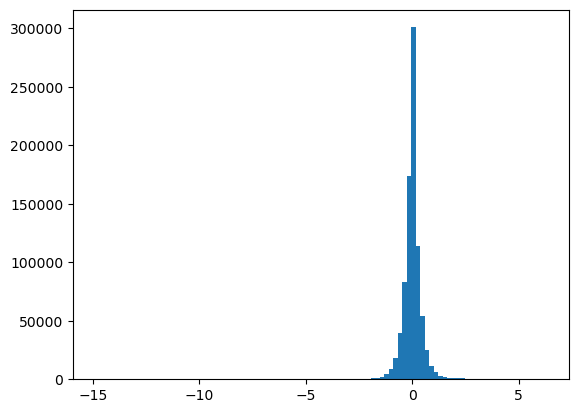

In [24]:
# make a histogram of all the values in the torch tensor E
plt.hist(E.flatten(), 100)

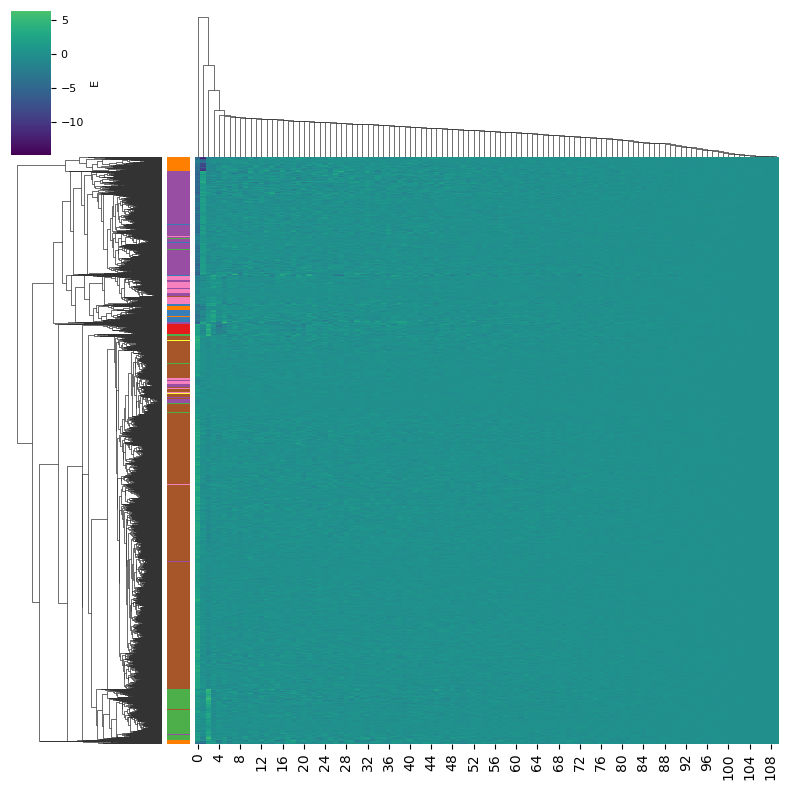

In [25]:
cluster = sns.clustermap(
    data=E,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'E'} 
    )
cluster.cax.set_ylabel('E', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

Text(0.5, 0, 'Cell Type')

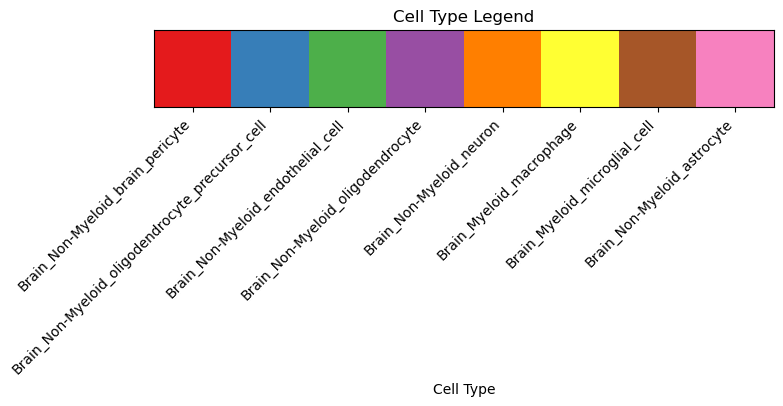

In [26]:
# print cell type color legend seperately
cell_type_colors
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right')
plt.xlabel("Cell Type")

In [27]:
# let's calculate silhouette score ussing assign_post
silhouette_score(E, cell_types)

0.03565715

In [28]:
# compute Davies-Bouldin Index 
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(E, cell_types) # closer to zero indicates better partition 

3.6152349512118143

In [29]:
# run umap on E
import umap
reducer = umap.UMAP()
embedding = reducer.fit_transform(E)

/scratch/ipykernel_146285/908986799.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'UMAP 2')

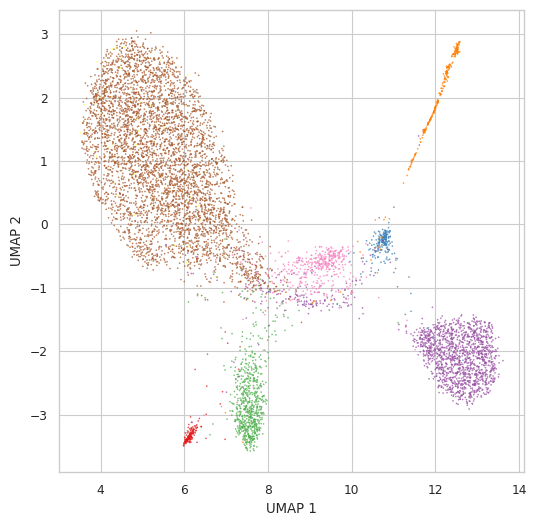

In [30]:
# plot UMAP 
# add whitegrid 
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.1,
    cmap="Spectral",
)
# xlab 
plt.xlabel("UMAP 1")
# ylab
plt.ylabel("UMAP 2")

([<matplotlib.axis.XTick at 0x7f9f312603a0>,
 [Text(0, 0, 'Brain_Non-Myeloid_brain_pericyte'),
  Text(1, 0, 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'),
  Text(2, 0, 'Brain_Non-Myeloid_endothelial_cell'),
  Text(3, 0, 'Brain_Non-Myeloid_oligodendrocyte'),
  Text(4, 0, 'Brain_Non-Myeloid_neuron'),
  Text(5, 0, 'Brain_Myeloid_macrophage'),
  Text(6, 0, 'Brain_Myeloid_microglial_cell'),
  Text(7, 0, 'Brain_Non-Myeloid_astrocyte')])

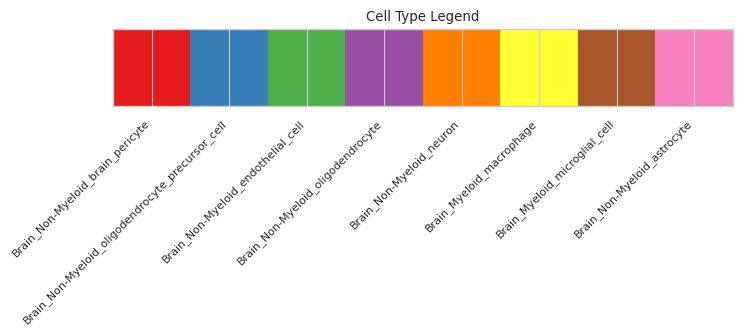

In [31]:
# plot cell_type_colors legend
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right', size=8)

In [32]:
# Now run PCA on E 
pca = PCA(n_components=10)
pca.fit(E)
print(pca.explained_variance_ratio_)
pcs = pca.transform(E)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

[0.23805921 0.08646492 0.05441038 0.02140547 0.01477759 0.01398318
 0.01341998 0.01315164 0.01250212 0.01238033]


/scratch/ipykernel_146285/170521529.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'PC 2')

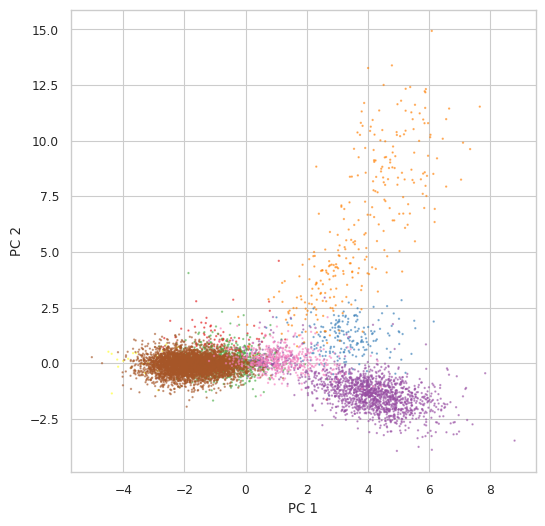

In [34]:
sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(6, 6))
plt.scatter(
    pcs_df["PC1"],
    pcs_df["PC2"],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8, alpha=0.5, 
    cmap="Spectral",
)
# xlab 
plt.xlabel("PC 1")
# ylab
plt.ylabel("PC 2")

## Evaluate effects of masking on nuclear norm pca E 
